###  Data Import & Cleaning Pipeline

In this section, we load multiple sheets from **New data.xlsx**, clean and harmonize the column names, assign region labels, and merge all datasets into a single DataFrame for further analysis.

---

###  Steps Performed

1. **Import required libraries**  
   - `pandas` for data manipulation  
   - `seaborn` and `matplotlib` for future visualization  

2. **Define sheet names and region labels**  
   Each sheet represents a device (`DH200X` or `IoT`) from a specific region (`Genova`, `Alban`, `Sandona`).  
   Region labels are added to track the source of each row.

3. **Load each sheet and clean the columns**  
   - Strip unwanted spaces in column names  
   - Harmonize inconsistent column names:  
     - `Temp_Overall` → `Temperature_Overall`  
     - `Hum_Overall` → `Humidity_Overall`  
     - `Temp_Coffee` → `Temperature_Coffee`  
     - `Humedity_Coffee` → `Humidity_Coffee`  

4. **Add a region label to each dataset**  
   This helps with grouping and plotting by region later.

5. **Concatenate all DataFrames**  
   All cleaned datasets are combined into one main DataFrame: `data`.

6. **Convert columns to numeric**  
   Temperature and humidity columns are safely converted using `errors='coerce'`.

7. **Drop rows missing `Temperature_Overall`**  
   Ensures clean final data for analysis.

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sheet_names = ['Genova DH200X','Genova IoT','Alban DH200X','Alban IoT','Sandona DH200X','Sandona IoT']
region_labels = ['GENOVADX','GENOVAIoT','AlbanDX','AlbanIoT','SandonaDX','SandonaIoT']

dfs = []

for sheet, region in zip(sheet_names, region_labels):
    df = pd.read_excel('New data.xlsx', sheet_name=sheet)
    df.columns = df.columns.str.strip()  # clean spaces

    # harmonize columns
    df = df.rename(columns={
        'Temp_Overall':'Temperature_Overall',
        'Hum_Overall':'Humidity_Overall',
        'Temp_Coffee':'Temperature_Coffee',
        'Humedity_Coffee':'Humidity_Coffee'
    })

    df['region'] = region
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# convert numeric safely
for col in ['Temperature_Coffee','Temperature_Overall','Humidity_Overall','Humidity_Coffee']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    else:
        data[col] = None
data = data.dropna(subset=['Temperature_Overall'], how='any').reset_index(drop=True)
print(df)



           Day      Hour        Section  Temperature_Overall  \
0   10/26/2025  08:00:00  M1 Superior                   22.1   
1   10/26/2025  08:00:00       M2 Medio                 22.1   
2   10/26/2025  08:00:00    M3 Inferior                 22.1   
3   10/26/2025  10:00:00   M1 Superior                  29.1   
4   10/26/2025  10:00:00       M2 Medio                 29.1   
..         ...       ...            ...                  ...   
82  10/30/2025  14:00:00       M2 Medio                 31.1   
83  10/30/2025  14:00:00    M3 Inferior                 31.1   
84  10/30/2025  16:00:00   M1 Superior                  32.7   
85  10/30/2025  16:00:00       M2 Medio                 32.7   
86  10/30/2025  16:00:00    M3 Inferior                 32.7   

    Humidity_Overall  Humidity_Coffee Temperature_Coffee  \
0               87.1            100.0              25.00   
1               87.1             92.5              23.50   
2               87.1             87.8              

###  KDE Plot: Temperature Distribution by Device Type (DH-200 vs IoT)

In this section, we create a new column called **`Source`** to identify whether each row comes from a **DH-200** device or an **IoT** device.  
This allows us to compare temperature distributions between the two device types for each city.

---

###  Steps Performed

1. **Create the `Source` column**  
   We classify each row as:
   - **DH-200** if the region label contains `"DX"`
   - **IoT** otherwise

2. **Loop through each city**  
   We analyze temperature distributions for:
   - Genova  
   - Alban  
   - Sandona  

3. **Check if both device types exist**  
   KDE plots require **both** DH-200 and IoT to show comparison.  
   If one is missing, the plot is skipped for that city.

4. **Generate KDE plots**  
   We use:
   - `sns.kdeplot` with `fill=True` for smooth density visualization  
   - `hue_order=['DH-200','IoT']` to keep consistent legend ordering  
   - `alpha=0.4` for transparency  
   - Clear titles for each city's temperature distribution  

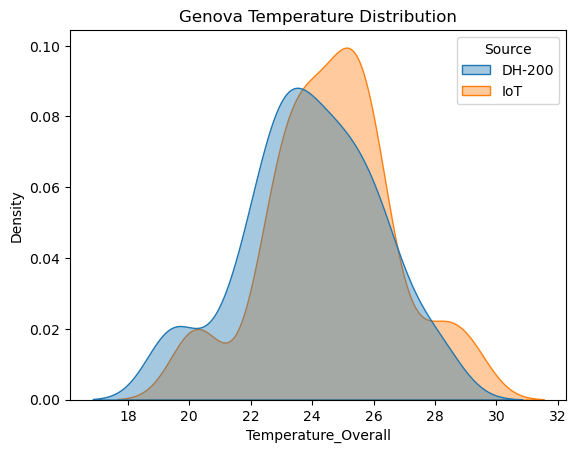

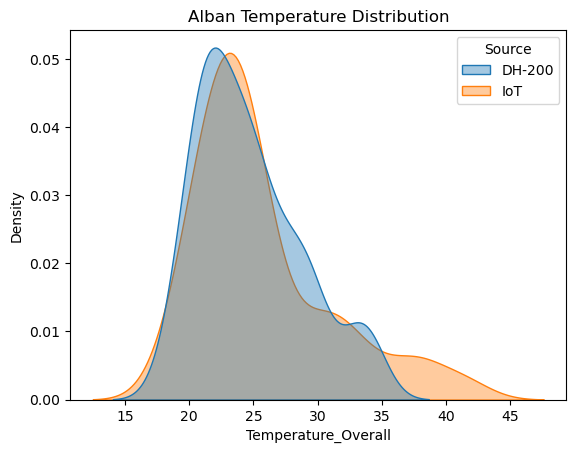

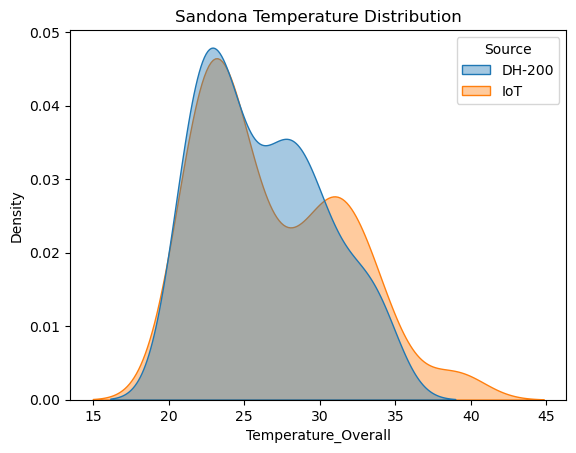

In [41]:
# create Source for legend
data['Source'] = data['region'].apply(lambda x: 'DH-200' if 'DX' in x else 'IoT')

# plot with hue_order to force DX and IoT
cities = ['Genova','Alban','Sandona']
for city in cities:
    subset = data[data['region'].str.contains(city, case=False)]
    if subset['Source'].nunique() < 2:
        print(f"{city} missing DX or IoT, skipping plot")
        continue
    sns.kdeplot(data=subset, x='Temperature_Overall', hue='Source', hue_order=['DH-200','IoT'], fill=True, alpha=0.4)
    plt.title(f'{city} Temperature Distribution')
    plt.show()


###  Summary Statistics for Temperature and Humidity

In this section, we compute descriptive statistics for both **Temperature** and **Humidity** across each **region** and **device type** (DH-200 vs IoT).  
This provides a clear comparison of central tendency and variability.

---

###  Metrics Computed

For each combination of **region** and **Source** (DH-200 or IoT), we calculate:

#### **Temperature (°C)**
- **Mean temperature**  
- **Median temperature**  
- **Mode temperature**  
- **Standard deviation**

#### **Humidity (%)**
- **Mean humidity**  
- **Median humidity**  
- **Mode humidity**  
- **Standard deviation**

The use of `lambda` functions ensures that the **mode** is extracted correctly, even when multiple modes exist (only the first is selected).  
All values are rounded to **2 decimal places** for readability.

In [42]:
# === Summary statistics for Temperature and Humidity ===
summary = (
    data.groupby(['region', 'Source'])
        .agg(
            mean_temp=('Temperature_Overall', 'mean'),
            median_temp=('Temperature_Overall', 'median'),
            mode_temp=('Temperature_Overall', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
            std_temp=('Temperature_Overall', 'std'),
            mean_hum=('Humidity_Overall', 'mean'),
            median_hum=('Humidity_Overall', 'median'),
            mode_hum=('Humidity_Overall', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
            std_hum=('Humidity_Overall', 'std')
        )
        .round(2)
        .reset_index()
)
from IPython.display import display
display(summary)


,region,Source,mean_temp,median_temp,mode_temp,std_temp,mean_hum,median_hum,mode_hum,std_hum
0,AlbanDX,DH-200,24.66,24.05,20.3,4.05,53.78,57.5,65.0,13.54
1,AlbanIoT,IoT,25.61,24.00,21.3,5.38,60.20,65.2,28.2,17.41
2,GENOVADX,DH-200,23.95,23.90,25.6,2.17,67.79,68.0,69.0,3.90
3,GENOVAIoT,IoT,24.60,24.70,25.1,2.09,68.44,69.0,69.0,3.62
4,SandonaDX,DH-200,26.23,25.70,21.6,3.96,67.28,73.0,81.0,16.15
5,SandonaIoT,IoT,26.88,25.10,21.9,4.74,66.43,68.1,53.2,15.38


This section performs a complete calibration analysis to model the relationship between **IoT humidity measurements** and **DH200X humidity measurements**.  
The goal is to evaluate which regression model best fits the transformation **DH200X = f(IoT)**.

---

##  1. Data Cleaning & Preparation

Before applying regression models:

- Column names are cleaned and harmonized  
- Only the required column **`Humidity_Coffee`** is converted to numeric  
- Rows with missing humidity values are removed  
- Summary of dataset size and region distribution is printed **before** and **after** cleaning

These steps ensure reliable modeling and avoid errors during transformation.

---

##  2. Regression Models Implemented

The function `fit_and_plot(region)` runs **five different regression techniques** for each region:

### **1️ Linear Regression**  
Models the relationship:  
\[
y = a x + b
\]  
Simple baseline model to check linear correlation.

---

### ** Polynomial Regression (degree 2)**  
Models nonlinear behavior:  
\[
y = ax^2 + bx + c
\]  
Useful when the transformation curve bends slightly.

---

### ** Exponential Regression**  
Models:  
\[
y = a e^{bx}
\]  
Requires strictly positive values.  
Good when growth/decay dynamics appear.

---

### ** Logarithmic Regression**  
Models:  
\[
y = a + b \ln(x)
\]  
Useful if DH200X increases fast at low IoT humidity then stabilizes.

---

### ** Power Regression**  
Models:  
\[
y = a x^b
\]  
Captures multiplicative or scaling relationships.

---

##  3. Visual Comparison

For each regression model:

- Raw data is shown using scatter plots  
- Fitted regression curves are plotted  
- R² score is computed and displayed  
- Plots include grid, labels, and legends  

This provides a clear visual and quantitative comparison of model performance.

---

##  4. Regions Analyzed

The regression pipeline is executed for:

- **Genova**
- **Alban**
- **Sandona**

For each region, IoT and DH200X pairings are aligned based on equal sample count.


=== BEFORE CLEANING ===
Total rows: 612

Missing values per column:
Day                          0
Hour                         0
Section                      0
Temperature_Overall          0
Humidity_Overall             0
Humidity_Coffee              0
Temperature_Coffee           0
region                       0
Updated_Coffee_humidity    306
dtype: int64

Rows by region:
region
Genova_DH200X     111
Genova_IoT        111
Alban_DH200X      108
Alban_IoT         108
Sandona_DH200X     87
Sandona_IoT        87
Name: count, dtype: int64

=== AFTER CLEANING ===
Total rows: 612

Rows by region:
region
Genova_DH200X     111
Genova_IoT        111
Alban_DH200X      108
Alban_IoT         108
Sandona_DH200X     87
Sandona_IoT        87
Name: count, dtype: int64

===== Region: Genova =====
DH200X samples: 111, IoT samples: 111
Linear: y = 0.3893 * x + -13.1919 | R² = 0.6733


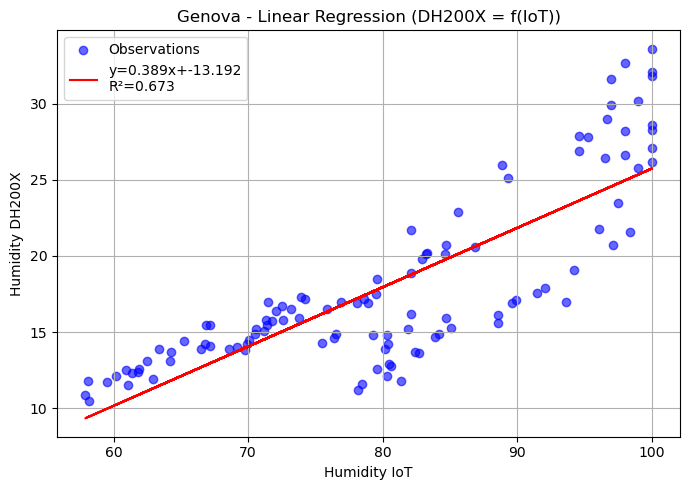

Polynomial: y = 0.0118x² + -1.5070x + 61.3151 | R² = 0.7622


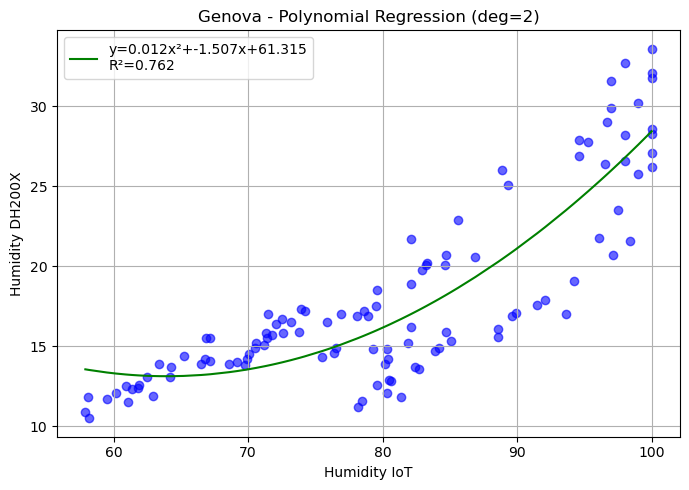

Exponential: y = 3.4349 * exp(0.0201x) | R² = 0.7125


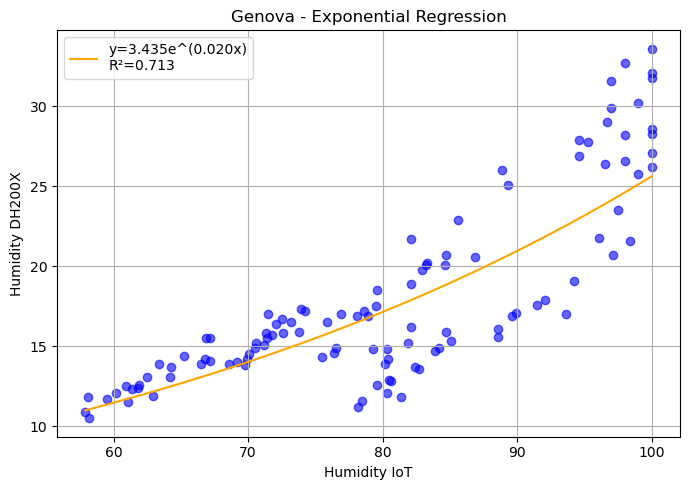

Logarithmic: y = -112.4088 + 29.8313ln(x) | R² = 0.6341


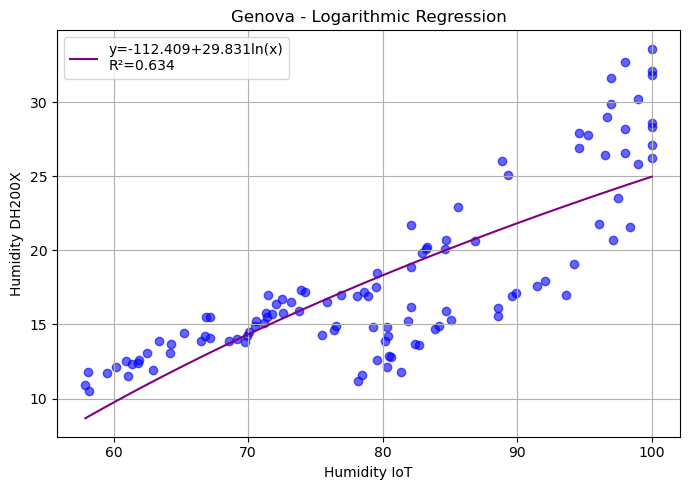

Power: y = 0.0193 * x^1.5535 | R² = 0.6762


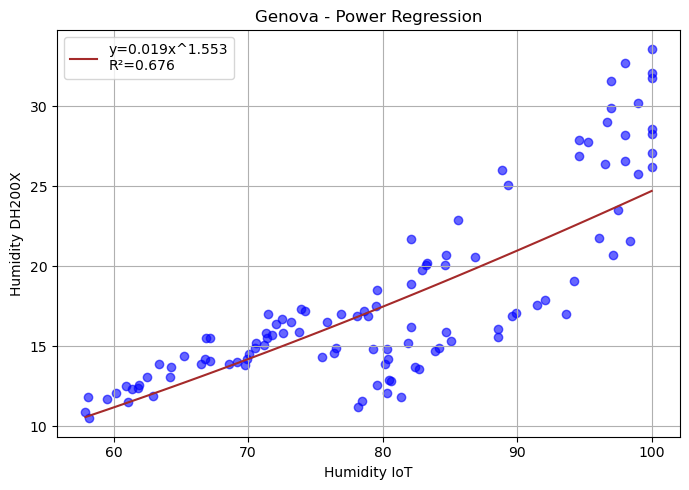


===== Region: Alban =====
DH200X samples: 108, IoT samples: 108
Linear: y = -0.0467 * x + 25.2196 | R² = 0.0117


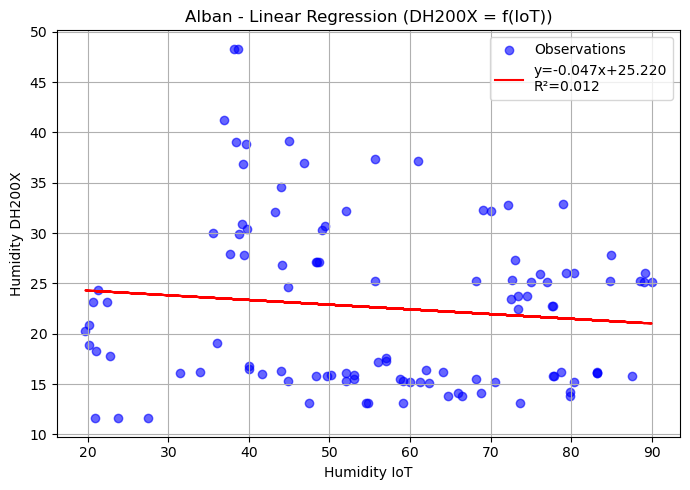

Polynomial: y = -0.0018x² + 0.1494x + 20.4941 | R² = 0.0183


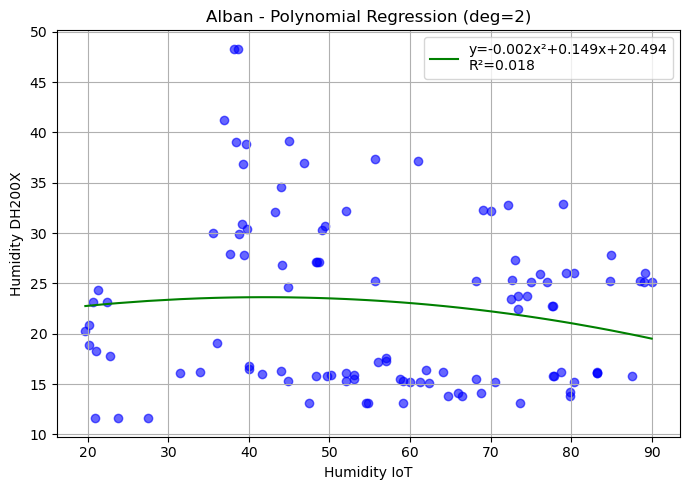

Exponential: y = 22.7483 * exp(-0.0013x) | R² = -0.0183


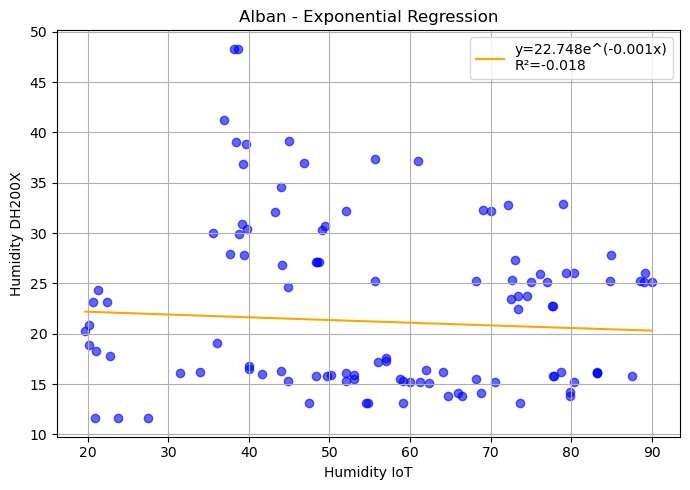

Logarithmic: y = 28.5198 + -1.4981ln(x) | R² = 0.0051


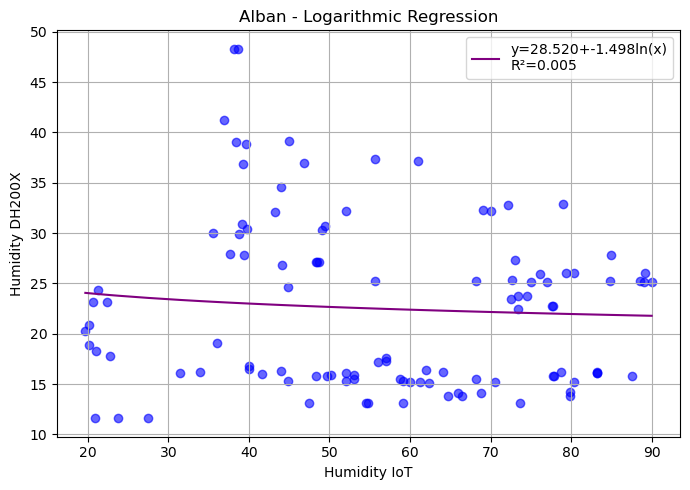

Power: y = 24.5500 * x^-0.0372 | R² = -0.0241


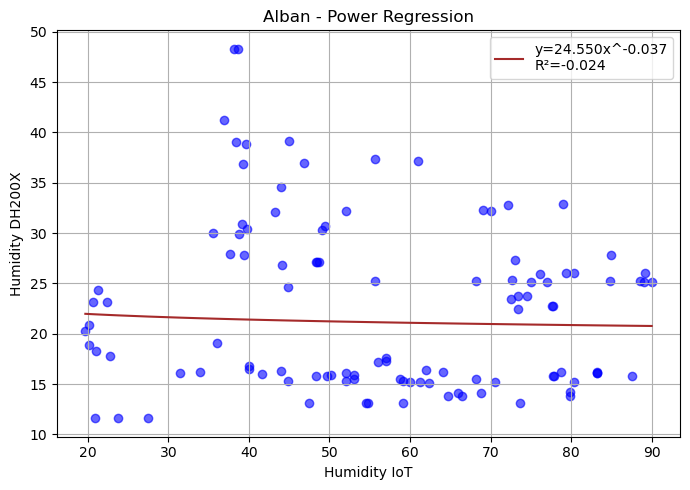


===== Region: Sandona =====
DH200X samples: 87, IoT samples: 87
Linear: y = 0.1913 * x + 6.7395 | R² = 0.2382


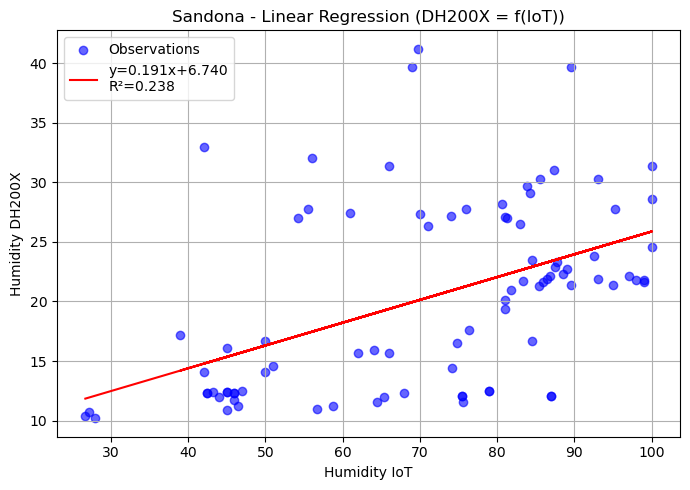

Polynomial: y = -0.0014x² + 0.3721x + 1.2819 | R² = 0.2423


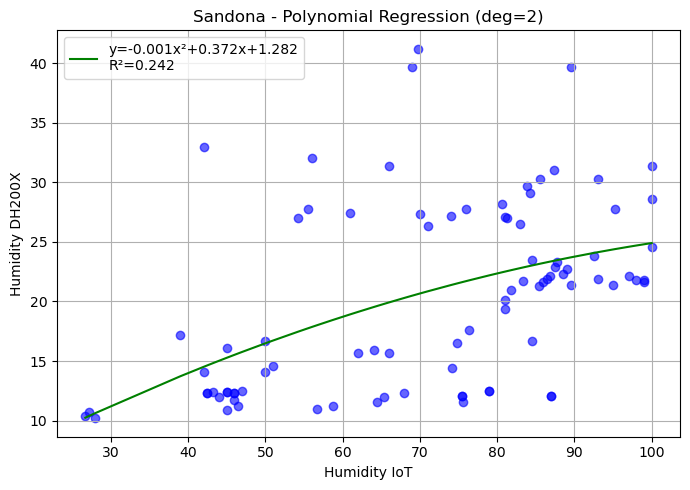

Exponential: y = 8.7411 * exp(0.0109x) | R² = 0.2123


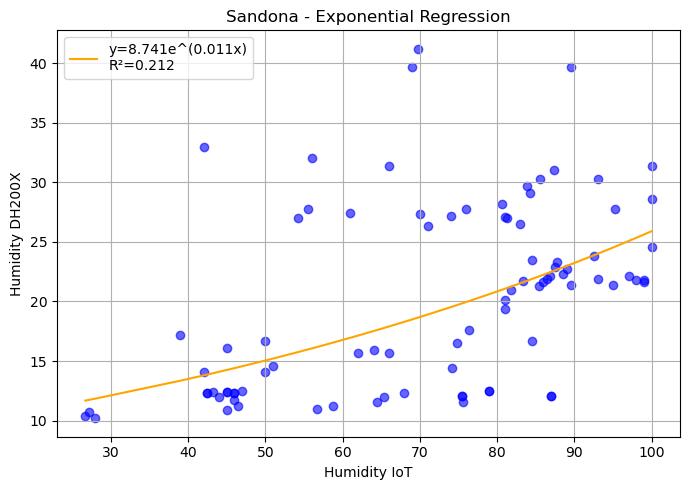

Logarithmic: y = -29.5625 + 11.8306ln(x) | R² = 0.2419


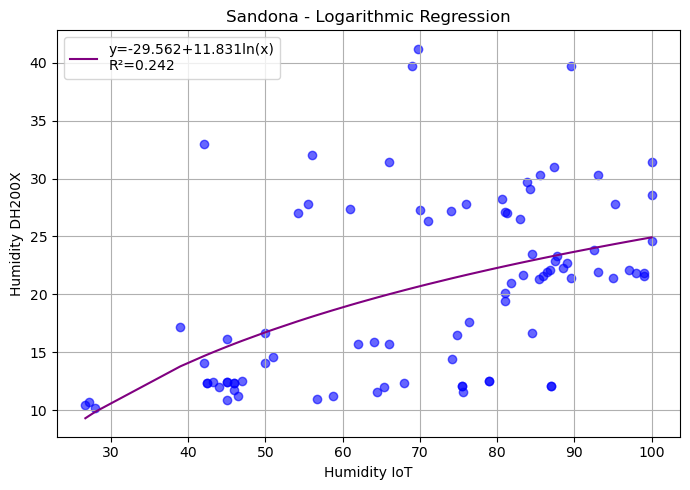

Power: y = 1.1161 * x^0.6710 | R² = 0.2236


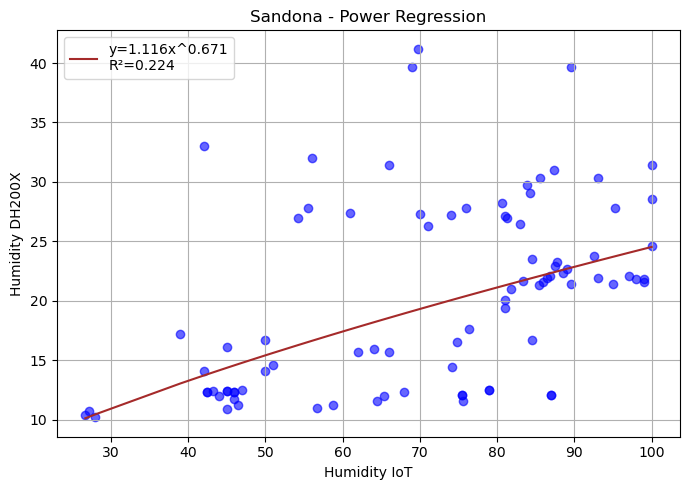

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score


# --- Clean columns ---
data.columns = data.columns.str.strip().str.replace('Humedity_Coffee', 'Humidity_Coffee')

print("\n=== BEFORE CLEANING ===")
print(f"Total rows: {len(data)}")
print("\nMissing values per column:")
print(data.isnull().sum())
print("\nRows by region:")
print(data['region'].value_counts())

# Only convert and check the Humidity_Coffee column we actually need
if 'Humidity_Coffee' in data.columns:
    data['Humidity_Coffee'] = pd.to_numeric(data['Humidity_Coffee'], errors='coerce')
    # Only drop rows where Humidity_Coffee is missing
    data = data.dropna(subset=['Humidity_Coffee'])
else:
    print("\n WARNING: 'Humidity_Coffee' column not found!")
    print("Available columns:", data.columns.tolist())

print("\n=== AFTER CLEANING ===")
print(f"Total rows: {len(data)}")
print("\nRows by region:")
print(data['region'].value_counts())

data.reset_index(drop=True, inplace=True)


# --- Main function ---
def fit_and_plot(region):
    print(f"\n===== Region: {region} =====")
    df_dx = data[data['region'] == f'{region}_DH200X'].reset_index(drop=True)
    df_iot = data[data['region'] == f'{region}_IoT'].reset_index(drop=True)

    print(f"DH200X samples: {len(df_dx)}, IoT samples: {len(df_iot)}")
    
    # Check if we have data
    if len(df_dx) == 0 or len(df_iot) == 0:
        print(f" No data available for {region}. Skipped.")
        return

    n = min(len(df_dx), len(df_iot))
    df_dx, df_iot = df_dx.iloc[:n], df_iot.iloc[:n]
    
    if n == 0:
        print(f" No matching data for {region}. Skipped.")
        return

    X = df_iot['Humidity_Coffee'].values.reshape(-1, 1)  # IoT (input)
    y = df_dx['Humidity_Coffee'].values                  # DH200X (target)

    # === 1. Linear ===
    lin_reg = LinearRegression().fit(X, y)
    y_pred_lin = lin_reg.predict(X)
    r2_lin = r2_score(y, y_pred_lin)
    print(f"Linear: y = {lin_reg.coef_[0]:.4f} * x + {lin_reg.intercept_:.4f} | R² = {r2_lin:.4f}")

    plt.figure(figsize=(7, 5))
    plt.scatter(X, y, color='blue', alpha=0.6, label='Observations')
    plt.plot(X, y_pred_lin, color='red', label=f'y={lin_reg.coef_[0]:.3f}x+{lin_reg.intercept_:.3f}\nR²={r2_lin:.3f}')
    plt.title(f"{region} - Linear Regression (DH200X = f(IoT))")
    plt.xlabel("Humidity IoT")
    plt.ylabel("Humidity DH200X")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # === 2. Polynomial (degree 2) ===
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    poly_reg = LinearRegression().fit(X_poly, y)
    y_pred_poly = poly_reg.predict(X_poly)
    r2_poly = r2_score(y, y_pred_poly)
    print(f"Polynomial: y = {poly_reg.coef_[2]:.4f}x² + {poly_reg.coef_[1]:.4f}x + {poly_reg.intercept_:.4f} | R² = {r2_poly:.4f}")

    plt.figure(figsize=(7, 5))
    plt.scatter(X, y, color='blue', alpha=0.6)
    sorted_idx = np.argsort(X.flatten())
    plt.plot(X[sorted_idx], y_pred_poly[sorted_idx], color='green',
             label=f'y={poly_reg.coef_[2]:.3f}x²+{poly_reg.coef_[1]:.3f}x+{poly_reg.intercept_:.3f}\nR²={r2_poly:.3f}')
    plt.title(f"{region} - Polynomial Regression (deg=2)")
    plt.xlabel("Humidity IoT")
    plt.ylabel("Humidity DH200X")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # === 3. Exponential: y = a * exp(bx) ===
    X_exp = X.flatten()
    mask = (y > 0)
    X_exp, y_exp = X_exp[mask], y[mask]
    
    if len(X_exp) == 0:
        print(" No positive data for exponential regression")
        return
    
    y_log = np.log(y_exp)
    exp_reg = LinearRegression().fit(X_exp.reshape(-1, 1), y_log)
    a = np.exp(exp_reg.intercept_)
    b = exp_reg.coef_[0]
    y_pred_exp = a * np.exp(b * X_exp)
    r2_exp = r2_score(y_exp, y_pred_exp)
    print(f"Exponential: y = {a:.4f} * exp({b:.4f}x) | R² = {r2_exp:.4f}")

    plt.figure(figsize=(7, 5))
    plt.scatter(X_exp, y_exp, color='blue', alpha=0.6)
    sorted_idx = np.argsort(X_exp)
    plt.plot(X_exp[sorted_idx], y_pred_exp[sorted_idx], color='orange', 
             label=f'y={a:.3f}e^({b:.3f}x)\nR²={r2_exp:.3f}')
    plt.title(f"{region} - Exponential Regression")
    plt.xlabel("Humidity IoT")
    plt.ylabel("Humidity DH200X")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # === 4. Logarithmic: y = a + b*ln(x) ===
    mask = X.flatten() > 0
    X_log, y_logr = X.flatten()[mask], y[mask]
    
    if len(X_log) == 0:
        print(" No positive data for logarithmic regression")
        return
    
    lnX = np.log(X_log).reshape(-1, 1)
    log_reg = LinearRegression().fit(lnX, y_logr)
    a, b = log_reg.intercept_, log_reg.coef_[0]
    y_pred_log = log_reg.predict(lnX)
    r2_log = r2_score(y_logr, y_pred_log)
    print(f"Logarithmic: y = {a:.4f} + {b:.4f}ln(x) | R² = {r2_log:.4f}")

    plt.figure(figsize=(7, 5))
    plt.scatter(X_log, y_logr, color='blue', alpha=0.6)
    sorted_idx = np.argsort(X_log)
    plt.plot(X_log[sorted_idx], y_pred_log[sorted_idx], color='purple', 
             label=f'y={a:.3f}+{b:.3f}ln(x)\nR²={r2_log:.3f}')
    plt.title(f"{region} - Logarithmic Regression")
    plt.xlabel("Humidity IoT")
    plt.ylabel("Humidity DH200X")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # === 5. Power: y = a * x^b ===
    mask = (X.flatten() > 0) & (y > 0)
    X_pow, y_pow = X.flatten()[mask], y[mask]
    
    if len(X_pow) == 0:
        print(" No positive data for power regression")
        return
    
    logX, logY = np.log(X_pow), np.log(y_pow)
    pow_reg = LinearRegression().fit(logX.reshape(-1, 1), logY)
    a = np.exp(pow_reg.intercept_)
    b = pow_reg.coef_[0]
    y_pred_pow = a * (X_pow ** b)
    r2_pow = r2_score(y_pow, y_pred_pow)
    print(f"Power: y = {a:.4f} * x^{b:.4f} | R² = {r2_pow:.4f}")

    plt.figure(figsize=(7, 5))
    plt.scatter(X_pow, y_pow, color='blue', alpha=0.6)
    sorted_idx = np.argsort(X_pow)
    plt.plot(X_pow[sorted_idx], y_pred_pow[sorted_idx], color='brown', 
             label=f'y={a:.3f}x^{b:.3f}\nR²={r2_pow:.3f}')
    plt.title(f"{region} - Power Regression")
    plt.xlabel("Humidity IoT")
    plt.ylabel("Humidity DH200X")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --- Run ---
for reg in ['Genova', 'Alban', 'Sandona']:
    fit_and_plot(reg)

# LSTM Modeling Pipeline for Predicting Coffee Humidity (M3 Section)

This section describes the full machine learning workflow used to train and evaluate LSTM models for predicting the *Updated Coffee Humidity* in Section **M3 Inferior** using previous sections (M1 Superior and M2 Medio) as training data.

---

## 1. Settings and Configuration

We begin by defining:

- The Excel file containing the data.
- The sheets corresponding to the regions.
- The training sections (M1, M2) and prediction section (M3).
- The LSTM sequence length (`n_steps`) and the number of M3 points used for fitting (`n_fit`).

These parameters control how the model processes time-series sequences and how many initial M3 observations are used to calibrate predictions.

---

## 2. Data Loading and Preparation

The data is imported from Excel sheets (Genova IoT and Sandona IoT).  
For each sheet:

- The `region` label is added.
- Column names are stripped of whitespace.
- Numerical columns (`Temperature_Overall`, `Humidity_Overall`, `Temperature_Coffee`, `Updated_Coffee_humidity`) are converted safely.
- Missing rows are removed.

The cleaned datasets are merged into a single DataFrame.

---

## 3. Region Encoding

A `LabelEncoder` is applied to convert the region names into numerical labels.  
The final feature matrix includes:

- Temperature_Overall  
- Humidity_Overall  
- Temperature_Coffee  
- Encoded Region  

The target variable is:

- Updated_Coffee_humidity

---

## 4. Creating Time-Series Sequences

A custom `create_sequences()` function transforms the data into supervised learning format:

- Each sample consists of `n_steps` consecutive rows of input features.
- The label is the humidity value following the sequence.
- If a region has insufficient data to form sequences, it is skipped.

This prepares the dataset for LSTM training.

---

## 5. LSTM Model Architecture

A general LSTM architecture is defined with:

- Three stacked LSTM layers (128 → 96 → 64 units)
- Dropout regularization between layers
- A Dense layer (optionally with activation)
- A final output neuron predicting humidity

The model uses:

- Nadam optimizer  
- MSE loss  
- MAE as an additional metric  

The activation function is configurable (ReLU, Tanh, Sigmoid, SELU, ELU, LeakyReLU).

---

## 6. Training and Prediction for Each Activation Function

For each activation:

1. The training data (M1 + M2) is extracted for each region.
2. Data is scaled using MinMaxScaler.
3. LSTM sequences are generated.
4. The model is trained using an 80/20 split (training/validation).
5. Training and validation losses are plotted.
6. The prediction process on M3 includes:
   - Initialization with the first `n_steps` points
   - Fitting the next `n_fit` points
   - Predicting all remaining points
7. Predictions are inverse-scaled back to real humidity values.
8. Evaluation metrics are computed:
   - MAE  
   - RMSE  
   - R² score  
9. Actual vs fitted vs predicted values are plotted over time.

This procedure is repeated for all activation functions and all regions.

---

## 7. Final Comparison Table

A summary table is printed at the end showing:

- Activation function  
- Region  
- MAE  
- RMSE  
- R²  

This allows direct comparison of performance across activation functions and regions.

---

## Summary

This workflow enables:

- Systematic comparison of activation functions in LSTM networks  
- Region-specific modeling of coffee drying behavior  
- Evaluation of prediction accuracy for M3 humidity  
- Visualization of training curves and prediction sequences  

The results highlight which activation functions provide the best performance for modeling the drying process.


Training with ReLU

--- Region: Genova ---
  Training samples: 16
  ✓ Training completed


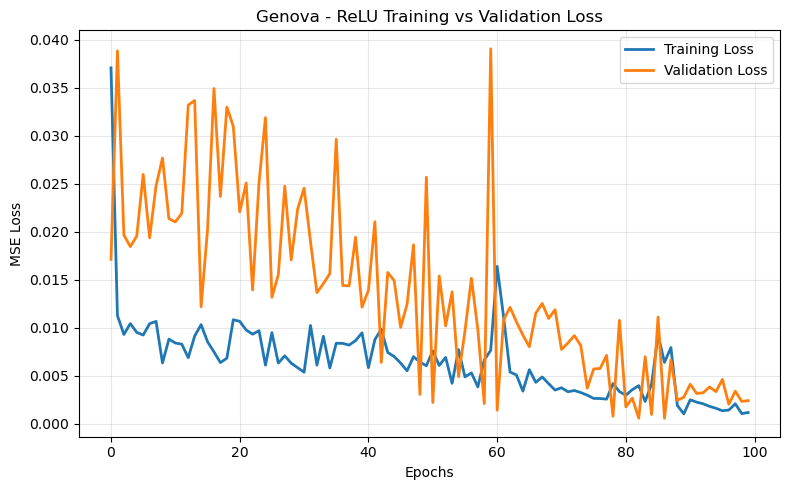

  Fitting on 1 M3 points...
  Predicting remaining 15 points...
  ✓ MAE=0.39, RMSE=0.52, R²=0.77


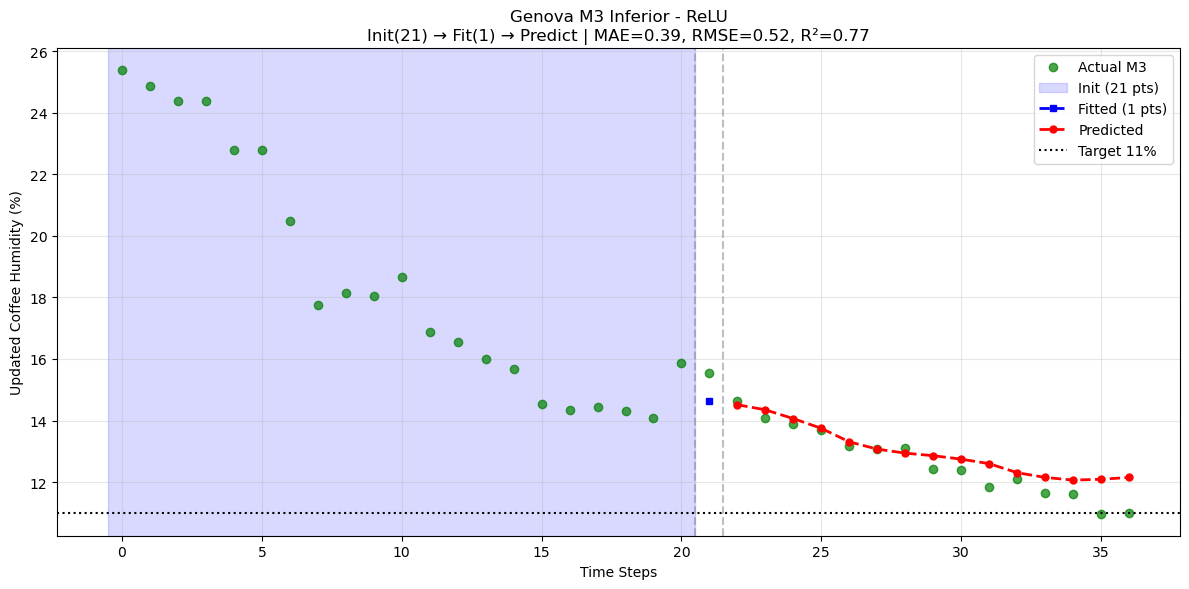


--- Region: Sandona ---
  Training samples: 7
  ✓ Training completed


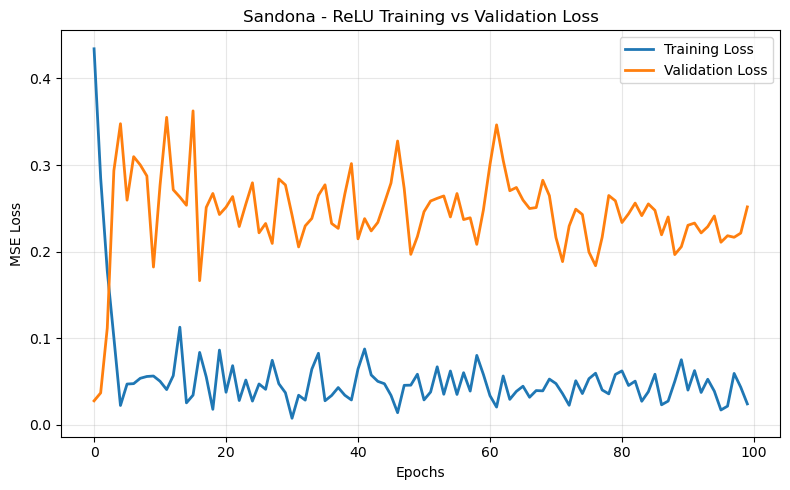

  Fitting on 1 M3 points...
  Predicting remaining 7 points...
  ✓ MAE=3.66, RMSE=4.65, R²=-0.35


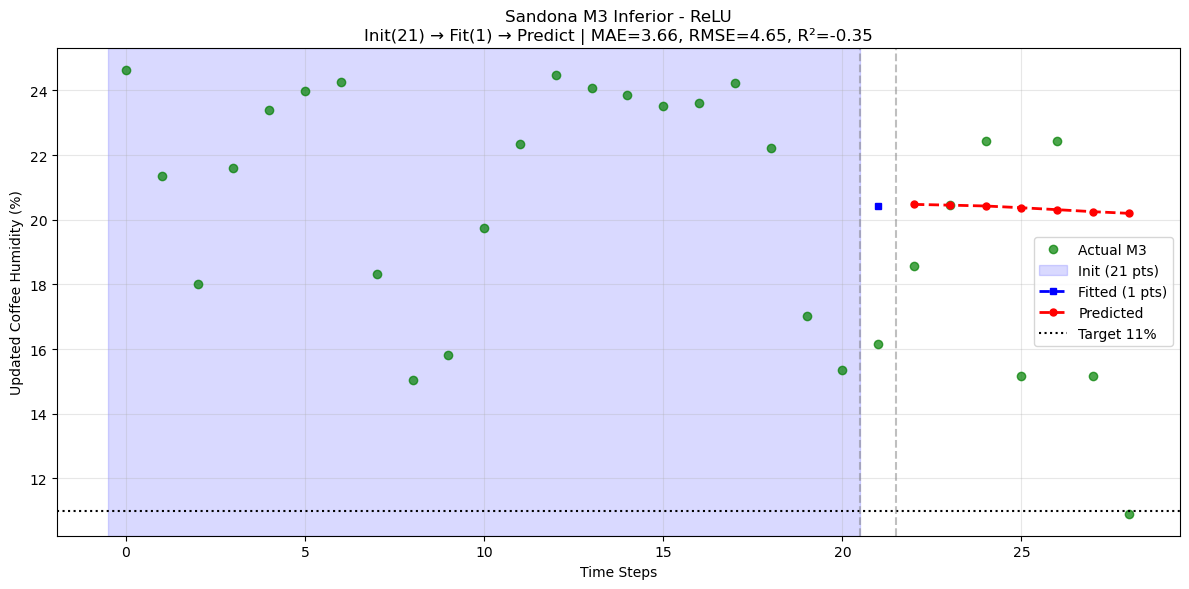


Training with Tanh

--- Region: Genova ---
  Training samples: 16
  ✓ Training completed


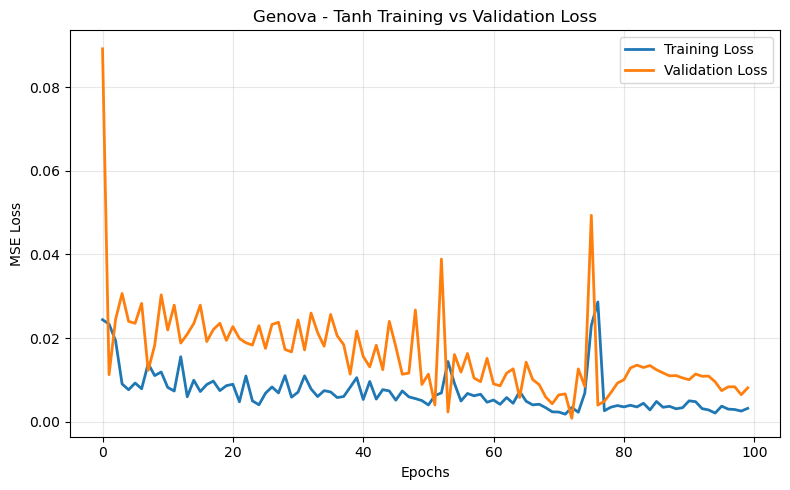

  Fitting on 1 M3 points...
  Predicting remaining 15 points...
  ✓ MAE=0.76, RMSE=0.92, R²=0.29


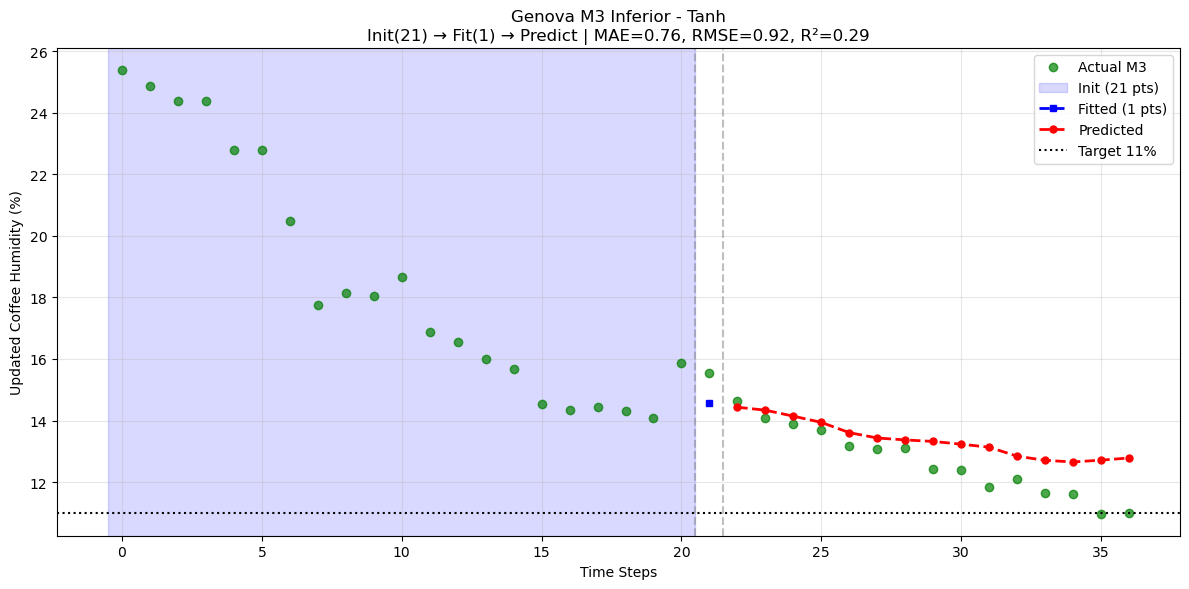


--- Region: Sandona ---
  Training samples: 7
  ✓ Training completed


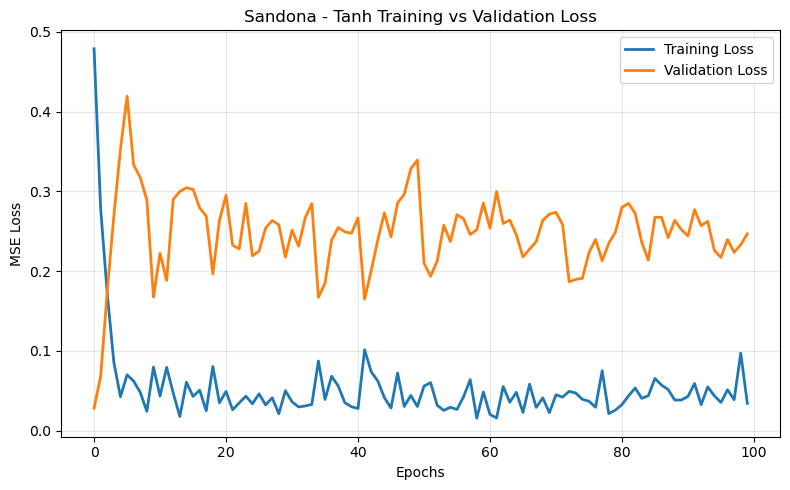

  Fitting on 1 M3 points...
  Predicting remaining 7 points...
  ✓ MAE=3.67, RMSE=4.64, R²=-0.34


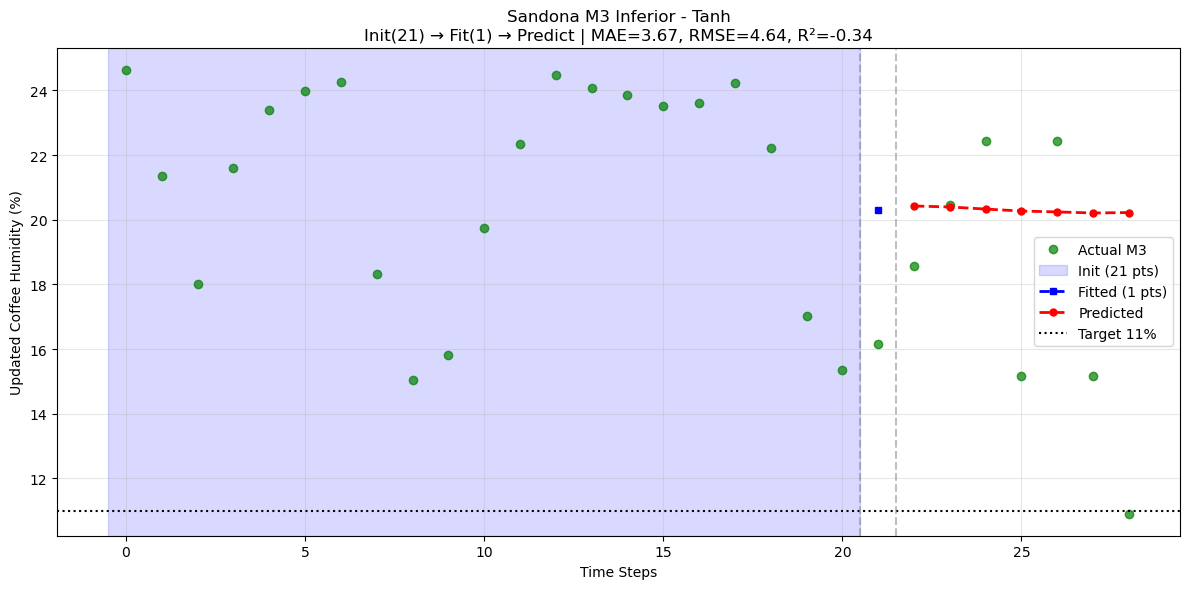


Training with Sigmoid

--- Region: Genova ---
  Training samples: 16
  ✓ Training completed


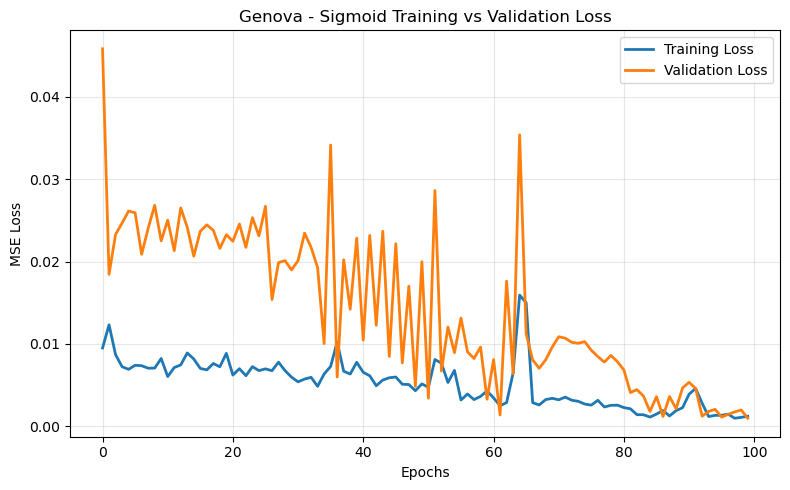

  Fitting on 1 M3 points...
  Predicting remaining 15 points...
  ✓ MAE=0.26, RMSE=0.35, R²=0.90


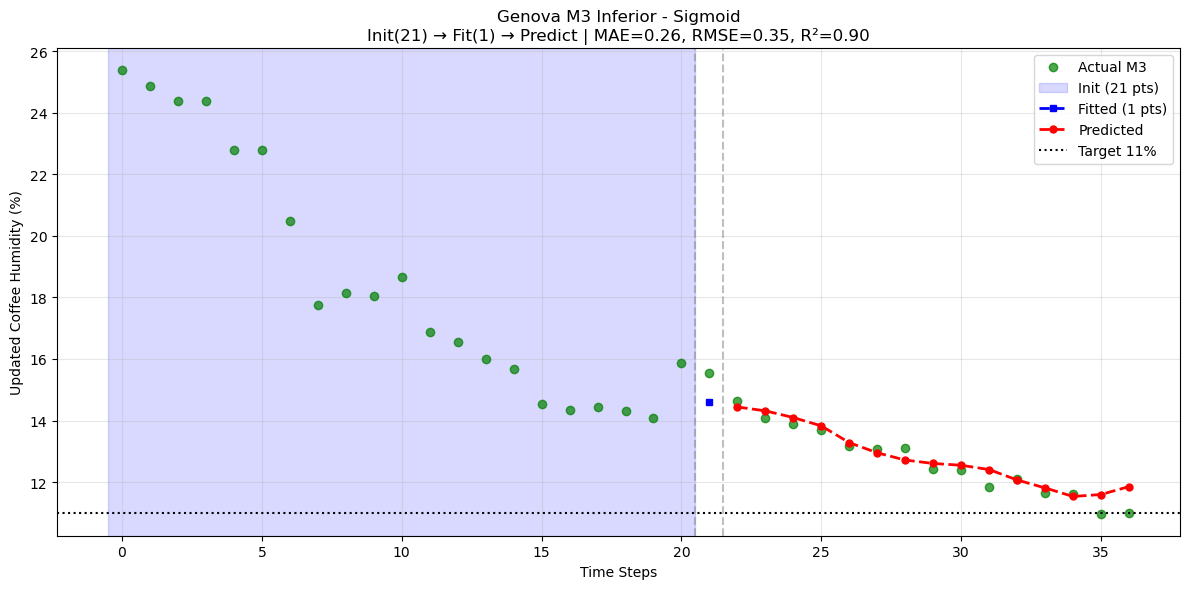


--- Region: Sandona ---
  Training samples: 7
  ✓ Training completed


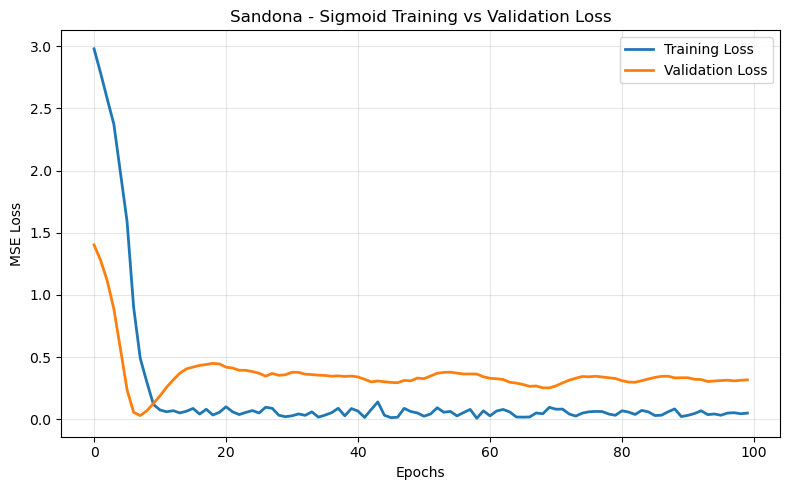

  Fitting on 1 M3 points...
  Predicting remaining 7 points...
  ✓ MAE=4.02, RMSE=5.18, R²=-0.68


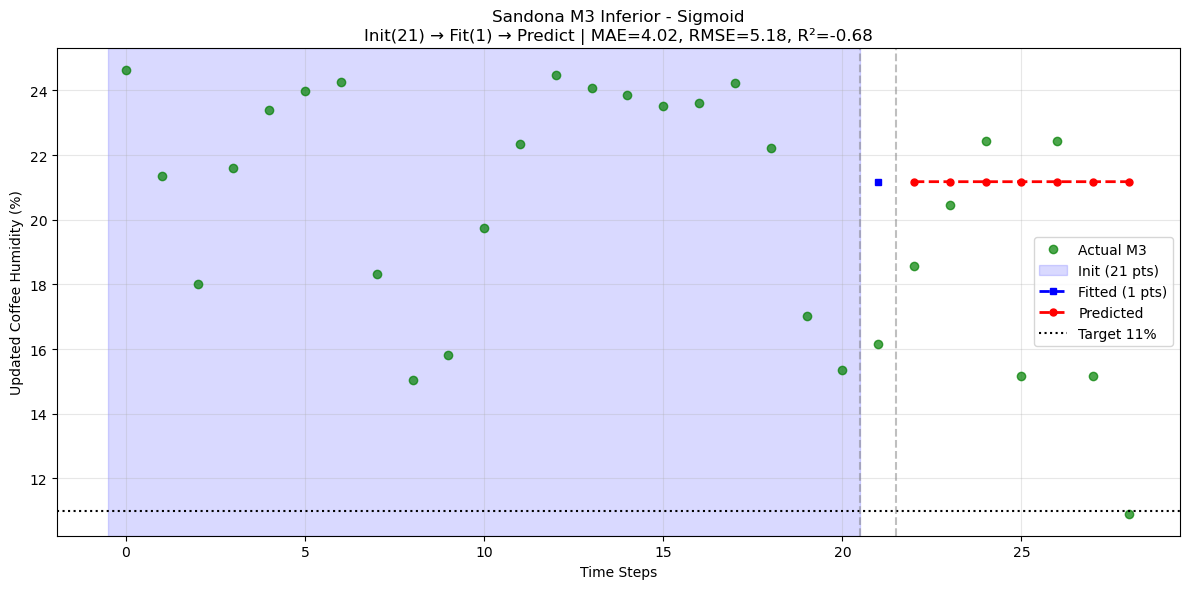


Training with SELU

--- Region: Genova ---
  Training samples: 16
  ✓ Training completed


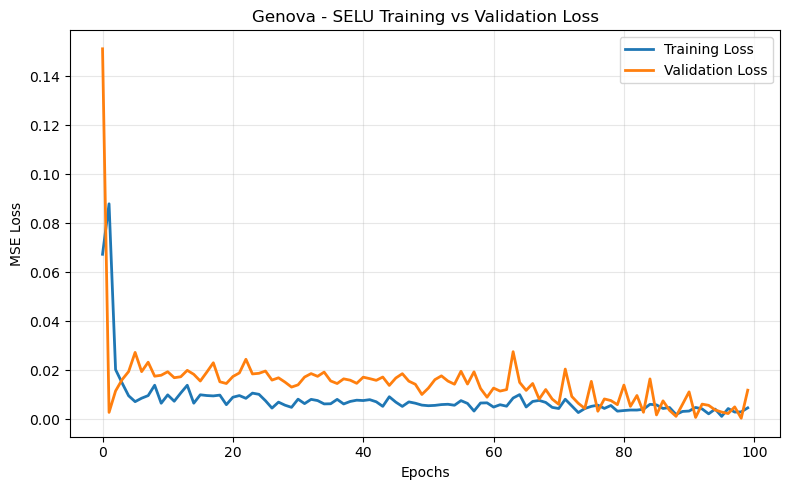

  Fitting on 1 M3 points...
  Predicting remaining 15 points...
  ✓ MAE=1.31, RMSE=1.38, R²=-0.59


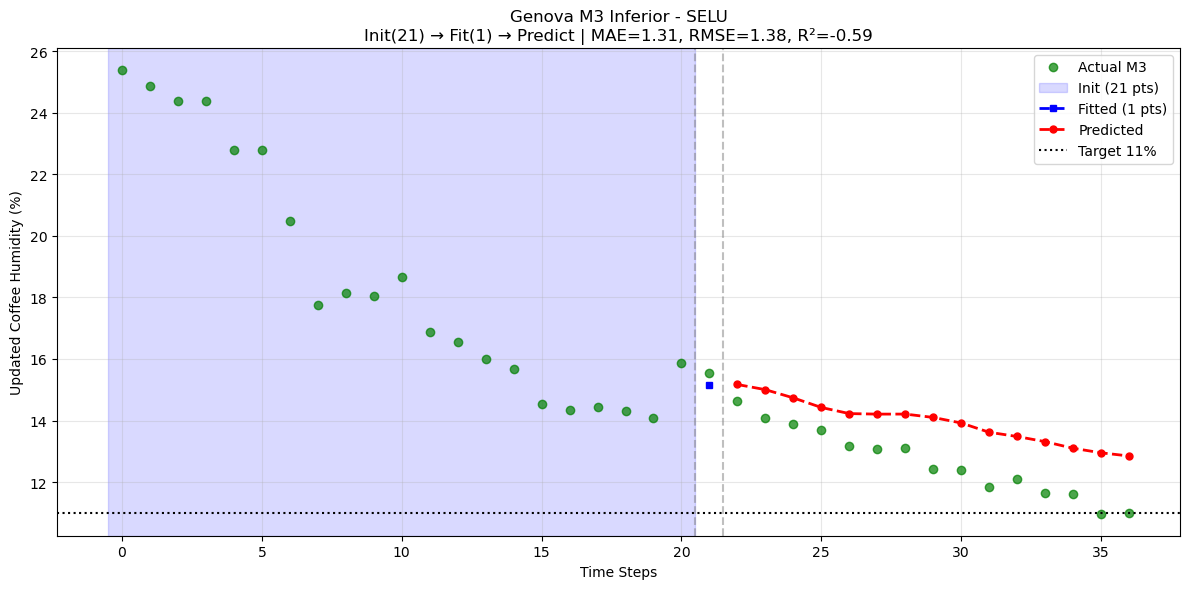


--- Region: Sandona ---
  Training samples: 7
  ✓ Training completed


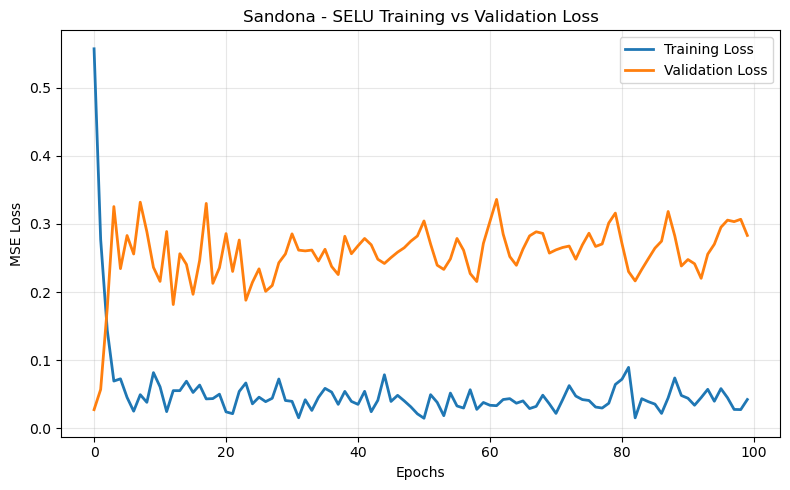

  Fitting on 1 M3 points...
  Predicting remaining 7 points...
  ✓ MAE=3.84, RMSE=4.95, R²=-0.53


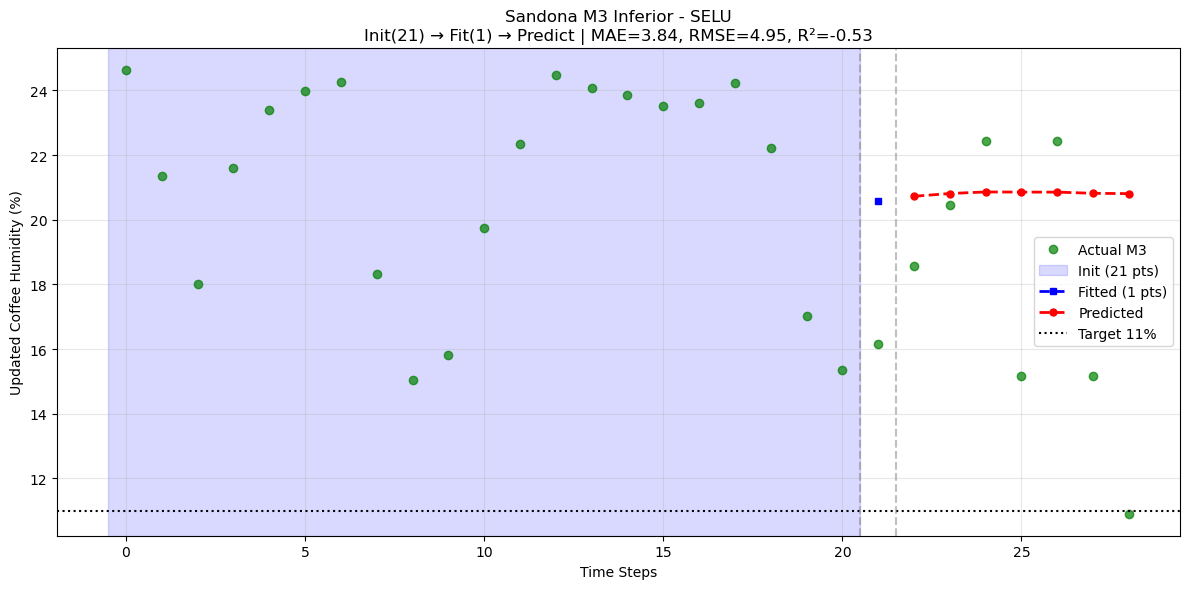


Training with ELU

--- Region: Genova ---
  Training samples: 16
  ✓ Training completed


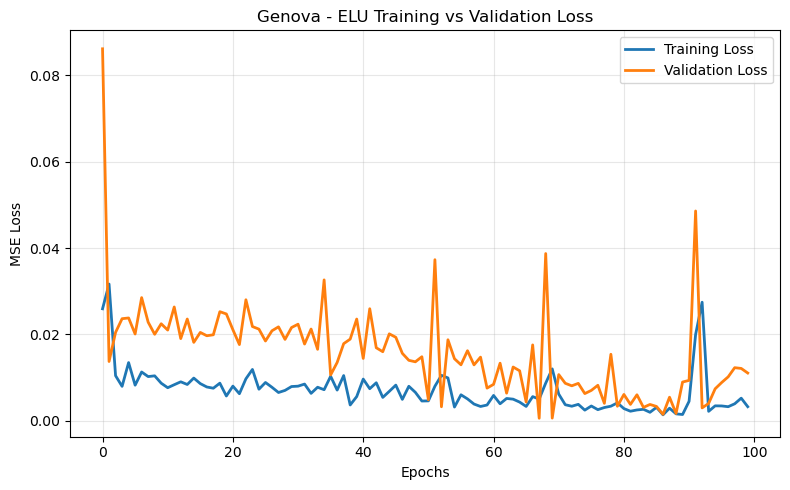

  Fitting on 1 M3 points...
  Predicting remaining 15 points...
  ✓ MAE=0.75, RMSE=0.95, R²=0.24


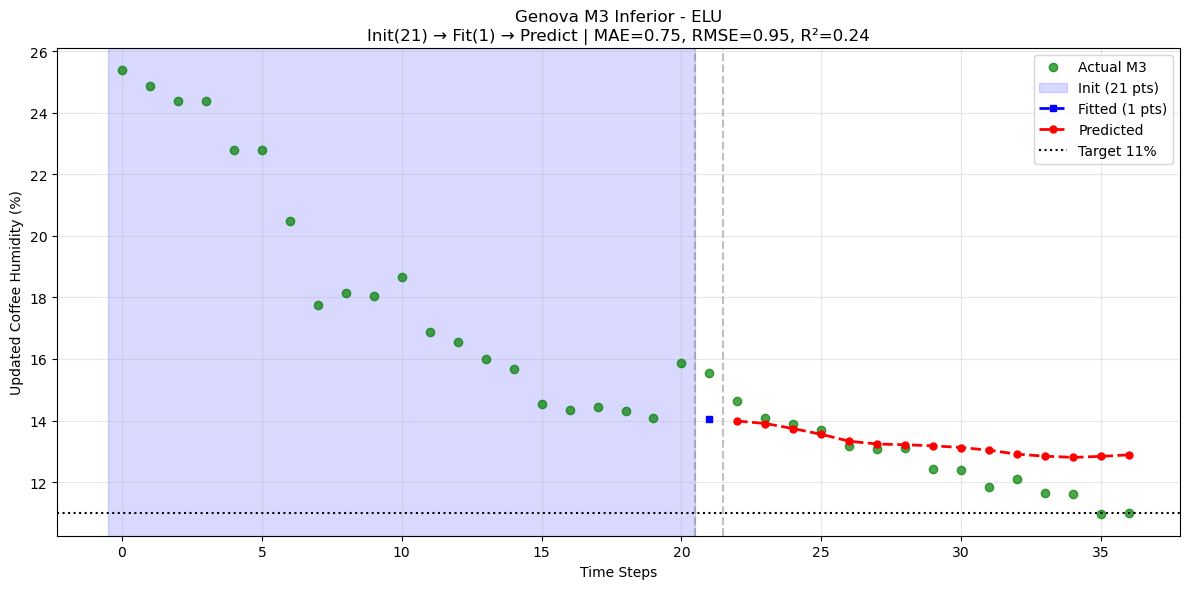


--- Region: Sandona ---
  Training samples: 7
  ✓ Training completed


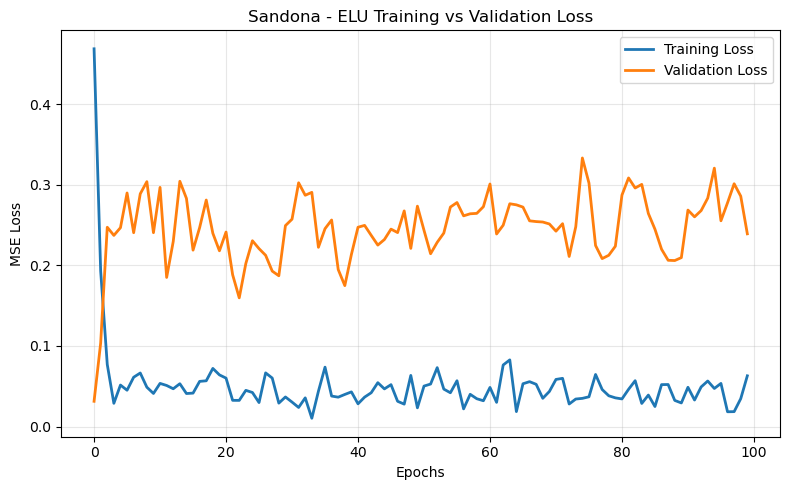

  Fitting on 1 M3 points...
  Predicting remaining 7 points...
  ✓ MAE=3.65, RMSE=4.60, R²=-0.32


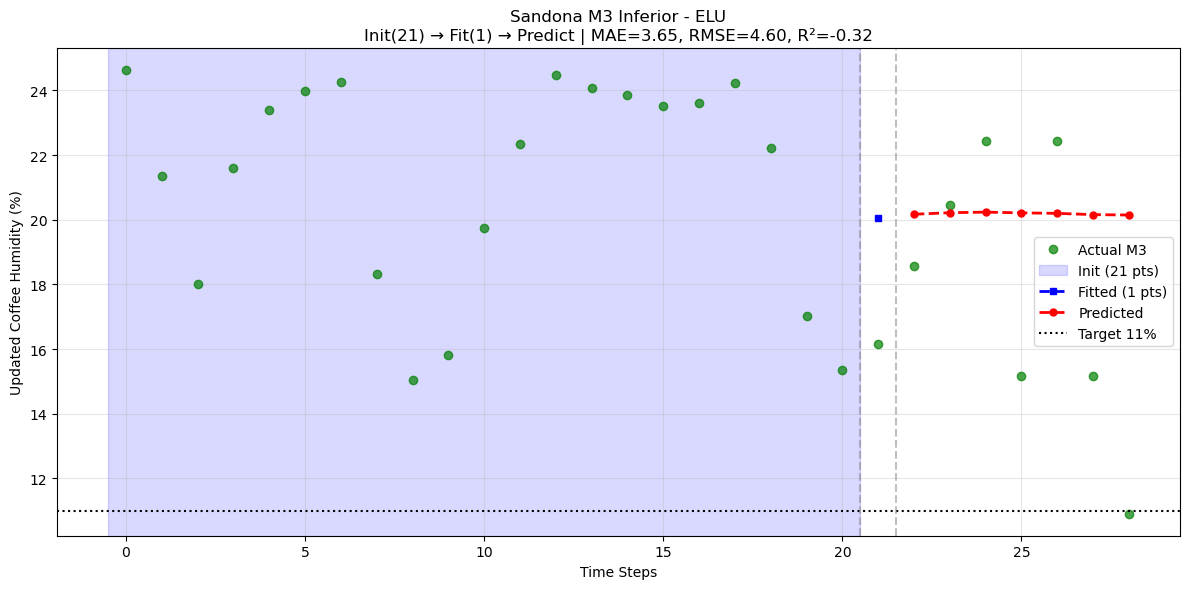


Training with LeakyReLU

--- Region: Genova ---
  Training samples: 16
  ✓ Training completed


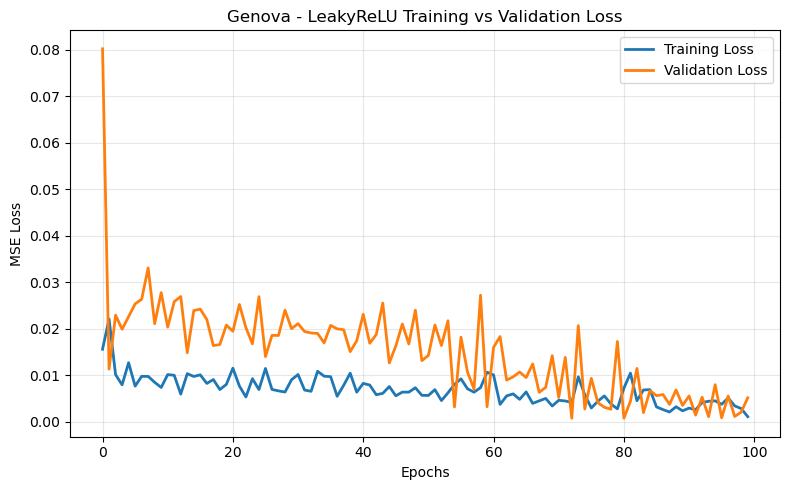

  Fitting on 1 M3 points...
  Predicting remaining 15 points...
  ✓ MAE=0.87, RMSE=0.93, R²=0.27


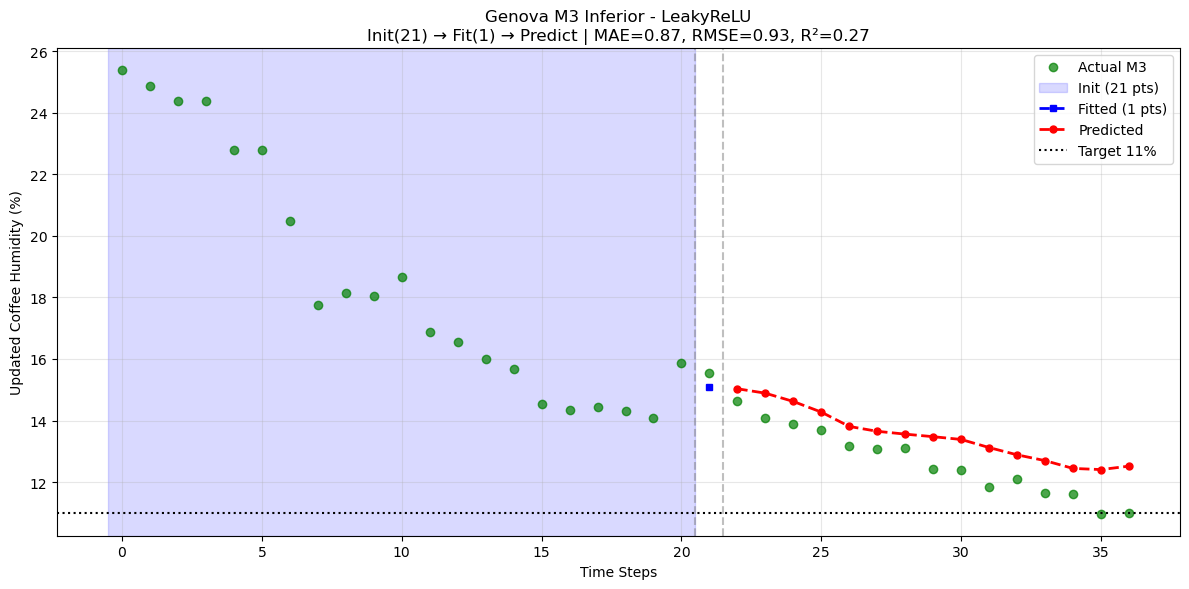


--- Region: Sandona ---
  Training samples: 7
  ✓ Training completed


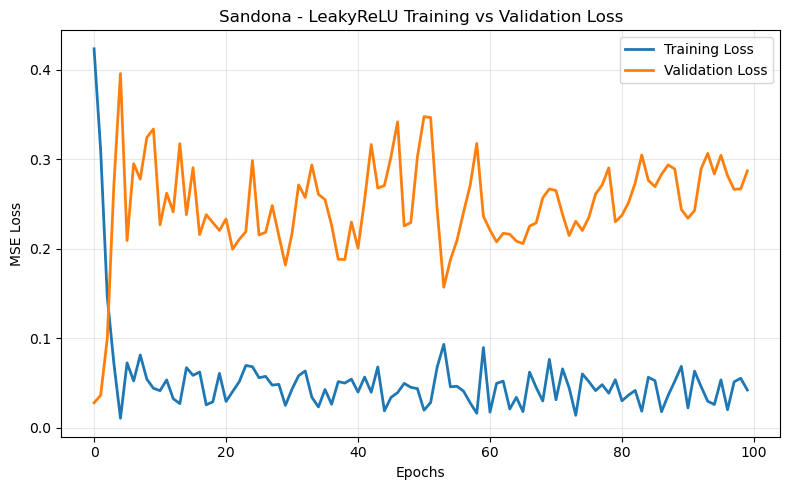

  Fitting on 1 M3 points...
  Predicting remaining 7 points...
  ✓ MAE=3.88, RMSE=4.93, R²=-0.51


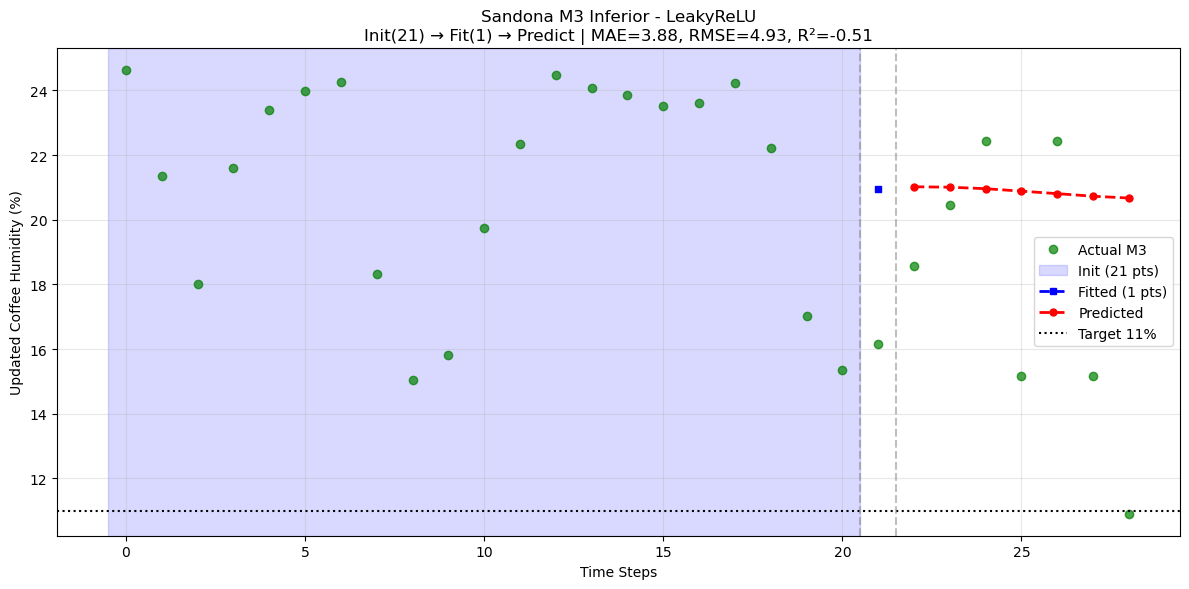


FINAL COMPARISON - M3 PREDICTION METRICS
Activation   | Region     | MAE        | RMSE       | R²        
----------------------------------------------------------------------
ReLU         | Genova     | 0.391      | 0.523      | 0.772     
ReLU         | Sandona    | 3.661      | 4.648      | -0.349    
Tanh         | Genova     | 0.761      | 0.921      | 0.292     
Tanh         | Sandona    | 3.669      | 4.641      | -0.345    
Sigmoid      | Genova     | 0.264      | 0.349      | 0.898     
Sigmoid      | Sandona    | 4.017      | 5.181      | -0.676    
SELU         | Genova     | 1.310      | 1.378      | -0.586    
SELU         | Sandona    | 3.842      | 4.955      | -0.533    
ELU          | Genova     | 0.746      | 0.952      | 0.244     
ELU          | Sandona    | 3.652      | 4.599      | -0.320    
LeakyReLU    | Genova     | 0.874      | 0.934      | 0.272     
LeakyReLU    | Sandona    | 3.876      | 4.926      | -0.515    


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.optimizers import Nadam

# ======================================
# 0. SETTINGS
# ======================================
DATA_FILE = 'New data.xlsx'
sheet_names = ['Genova IoT', 'Sandona IoT']
region_labels = ['Genova', 'Sandona']
sections_train = ['M1 Superior', 'M2 Medio']
sections_predict = 'M3 Inferior'
n_steps = 21  # LSTM sequence length
n_fit = 1    # Number of M3 points to use for fitting

# ======================================
# 1. LOAD AND PREPARE DATA
# ======================================
dfs = []
for sheet, region in zip(sheet_names, region_labels):
    df = pd.read_excel(DATA_FILE, sheet_name=sheet)
    df['region'] = region
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data.columns = data.columns.str.strip()

cols = ['Temperature_Overall', 'Humidity_Overall', 'Temperature_Coffee', 'Updated_Coffee_humidity']
for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data.dropna(subset=cols, inplace=True)
data.reset_index(drop=True, inplace=True)

# ======================================
# 2. ENCODE REGION
# ======================================
le_region = LabelEncoder()
data['region_encoded'] = le_region.fit_transform(data['region'].astype(str))

features = ['Temperature_Overall', 'Humidity_Overall', 'Temperature_Coffee', 'region_encoded']
target = 'Updated_Coffee_humidity'

# ======================================
# 3. CREATE SEQUENCES FUNCTION
# ======================================
def create_sequences(df, n_steps):
    X, y = [], []
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    if len(X) == 0:
        return np.empty((0, n_steps, len(features))), np.empty((0,))
    return np.array(X), np.array(y)

# ======================================
# 4. BUILD LSTM MODEL
# ======================================
def build_model(input_shape, activation_fn):
    use_leaky = isinstance(activation_fn, LeakyReLU)
    dense_activation = activation_fn if isinstance(activation_fn, str) else None

    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(96, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(32) if not dense_activation else Dense(32, activation=dense_activation)
    ])
    if use_leaky:
        model.add(activation_fn)
    model.add(Dense(1))
    model.compile(optimizer=Nadam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# ======================================
# 5. ACTIVATIONS
# ======================================
activations = {
    'ReLU': 'relu',
    'Tanh': 'tanh',
    'Sigmoid': 'sigmoid',
    'SELU': 'selu',
    'ELU': 'elu',
    'LeakyReLU': LeakyReLU(negative_slope=0.01)
}

results = {}

# ======================================
# 6. TRAIN + PREDICT FOR EACH ACTIVATION
# ======================================
for activation_name, activation in activations.items():
    print(f"\n{'='*60}")
    print(f"Training with {activation_name}")
    print('='*60)
    
    results[activation_name] = {'models': {}, 'val_metrics': {}, 'predictions': {}}

    for region in region_labels:
        print(f"\n--- Region: {region} ---")

        # GET TRAINING DATA (M1 + M2)
        train_region = data[(data['region']==region) & (data['Section'].isin(sections_train))].copy()
        if len(train_region) < n_steps + 1:
            print(f"  ⚠ Not enough training data ({len(train_region)} rows), skipping...")
            results[activation_name]['val_metrics'][region] = {'MAE': np.nan, 'RMSE': np.nan, 'R2': np.nan}
            continue

        # NORMALIZE TRAINING DATA
        scaler = MinMaxScaler()
        needed_cols = features + [target]
        train_region[needed_cols] = train_region[needed_cols].astype(float)
        train_region.loc[:, needed_cols] = scaler.fit_transform(train_region[needed_cols])

        # CREATE SEQUENCES AND TRAIN
        X_train, y_train = create_sequences(train_region, n_steps)
        if len(X_train) == 0:
            print(f"  ⚠ No sequences created, skipping...")
            continue

        print(f"  Training samples: {len(X_train)}")
        model = build_model((X_train.shape[1], X_train.shape[2]), activation)

        # --- TRAIN MODEL AND CAPTURE HISTORY ---
        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=64,
            verbose=0,
            validation_split=0.2
        )

        results[activation_name]['models'][region] = model
        print(f"  ✓ Training completed")

        # --- PLOT TRAINING & VALIDATION LOSS ---
        plt.figure(figsize=(8, 5))
        plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
        plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
        plt.title(f'{region} - {activation_name} Training vs Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('MSE Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # GET M3 DATA FOR PREDICTION
        m3_region = data[(data['region']==region) & (data['Section']==sections_predict)].copy()
        if len(m3_region) < n_steps + n_fit + 1:
            print(f"   Not enough M3 data ({len(m3_region)} rows), need at least {n_steps + n_fit + 1}")
            results[activation_name]['val_metrics'][region] = {'MAE': np.nan, 'RMSE': np.nan, 'R2': np.nan}
            continue

        # NORMALIZE M3 DATA (using same scaler from training)
        m3_region[needed_cols] = m3_region[needed_cols].astype(float)
        m3_region.loc[:, needed_cols] = scaler.transform(m3_region[needed_cols])

        # STORE ACTUAL M3 VALUES (unscaled)
        all_actual = m3_region[target].values
        tmp = np.zeros((len(all_actual), len(features) + 1))
        tmp[:, -1] = all_actual
        all_actual_unscaled = scaler.inverse_transform(tmp)[:, -1]

        # INITIALIZE with first n_steps points from M3
        initial_seq = m3_region[features].iloc[:n_steps].values.copy()
        current_seq = initial_seq.copy()

        # FITTING PHASE
        print(f"  Fitting on {n_fit} M3 points...")
        fitted_predictions = []
        for j in range(n_steps, n_steps + n_fit):
            pred = model.predict(current_seq[np.newaxis, :, :], verbose=0)[0, 0]
            fitted_predictions.append(pred)
            next_feats = m3_region[features].iloc[j].values.copy()
            current_seq = np.vstack([current_seq[1:], next_feats])

        # PREDICTION PHASE
        print(f"  Predicting remaining {len(m3_region) - n_steps - n_fit} points...")
        predictions = []
        for j in range(n_steps + n_fit, len(m3_region)):
            pred = model.predict(current_seq[np.newaxis, :, :], verbose=0)[0, 0]
            predictions.append(pred)
            next_feats = m3_region[features].iloc[j].values.copy()
            current_seq = np.vstack([current_seq[1:], next_feats])

        # UNSCALE PREDICTIONS
        def unscale(preds):
            tmp = np.zeros((len(preds), len(features) + 1))
            tmp[:, -1] = preds
            return scaler.inverse_transform(tmp)[:, -1]

        fitted_unscaled = unscale(fitted_predictions)
        pred_unscaled = unscale(predictions)

        # CALCULATE METRICS
        y_true = all_actual_unscaled[n_steps + n_fit:]
        y_pred = pred_unscaled
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        results[activation_name]['val_metrics'][region] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        results[activation_name]['predictions'][region] = {
            'actual': all_actual_unscaled,
            'fitted': fitted_unscaled,
            'predicted': pred_unscaled
        }
        print(f"   MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.2f}")

        # --- PLOT RESULTS ---
        plt.figure(figsize=(12, 6))
        plt.plot(all_actual_unscaled, 'go', label='Actual M3', markersize=6, alpha=0.7)
        plt.axvspan(-0.5, n_steps-0.5, alpha=0.15, color='blue', label=f'Init ({n_steps} pts)')
        fitted_idx = np.arange(n_steps, n_steps + n_fit)
        plt.plot(fitted_idx, fitted_unscaled, 'bs--', label=f'Fitted ({n_fit} pts)', linewidth=2, markersize=5)
        pred_idx = np.arange(n_steps + n_fit, len(all_actual_unscaled))
        plt.plot(pred_idx, pred_unscaled, 'ro--', label='Predicted', linewidth=2, markersize=5)
        plt.axhline(y=11, color='k', linestyle=':', label='Target 11%', linewidth=1.5)
        plt.axvline(x=n_steps-0.5, color='gray', linestyle='--', alpha=0.5)
        plt.axvline(x=n_steps+n_fit-0.5, color='gray', linestyle='--', alpha=0.5)
        plt.title(f'{region} M3 Inferior - {activation_name}\n' +
                  f'Init({n_steps}) → Fit({n_fit}) → Predict | ' +
                  f'MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.2f}')
        plt.xlabel('Time Steps')
        plt.ylabel('Updated Coffee Humidity (%)')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# ======================================
# 7. FINAL COMPARISON TABLE
# ======================================
print("\n" + "="*70)
print("FINAL COMPARISON - M3 PREDICTION METRICS")
print("="*70)
header = f"{'Activation':<12} | {'Region':<10} | {'MAE':<10} | {'RMSE':<10} | {'R²':<10}"
print(header)
print("-"*70)
for act in activations.keys():
    for region in region_labels:
        m = results[act]['val_metrics'].get(region, {'MAE': np.nan, 'RMSE': np.nan, 'R2': np.nan})
        print(f"{act:<12} | {region:<10} | {m['MAE']:<10.3f} | {m['RMSE']:<10.3f} | {m['R2']:<10.3f}")
print("="*70)
